# Exercise 3
## Action Recognition on KTH-Actions with RNNs

## Imports

In [1]:
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

## Config

In [2]:
DATA_ROOT   = Path("/home/nfs/data/hdd_datasets/kth_actions")
NUM_FRAMES  = 10
BATCH_SIZE  = 32
NUM_WORKERS = 4
NUM_EPOCHS  = 15
LR          = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch._dynamo.reset()

Using device: cuda


## KTH Dataset

The KTH Actions dataset contains 6 action classes performed by 25 subjects.
We split by person ID:
- **Train**: persons 1–16
- **Valid**: persons 17–20
- **Test**: persons 21–25

Each video is split into non-overlapping subsequences of NUM_FRAMES frames.

In [3]:
class KTHDataset(Dataset):
    """ KTH Actions dataset; splits videos into fixed-length subsequences, split by person ID. """

    CLASSES = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
    CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

    SPLIT_PERSONS = {
        "train": list(range(1, 17)),
        "valid": list(range(17, 21)),
        "test":  list(range(21, 26)),
    }

    def __init__(self, root, split="train", num_frames=10, stride=None, transform=None, preload=True):
        assert split in self.SPLIT_PERSONS
        self.num_frames = num_frames
        self.transform  = transform
        persons         = self.SPLIT_PERSONS[split]
        stride          = stride if stride is not None else num_frames   # default: non-overlapping

        processed_root = Path(root) / "processed"
        self.samples = []   # (sorted_frame_paths, start_idx, label)

        for cls in self.CLASSES:
            for video_dir in sorted((processed_root / cls).iterdir()):
                if not video_dir.is_dir():
                    continue
                stem = video_dir.name.split("_")[0].replace("person", "")
                if not stem.isdigit():
                    continue
                person_id = int(stem)
                if person_id not in persons:
                    continue
                frame_paths = sorted(video_dir.glob("*.png"))
                n = len(frame_paths)
                if n < num_frames:
                    continue
                label = self.CLASS_TO_IDX[cls]
                for start in range(0, n - num_frames + 1, stride):
                    self.samples.append((frame_paths, start, label))

        print(f"[{split:>5}] {len(self.samples)} subsequences from {len(persons)} persons  (stride={stride})")

        # pre-load all unique frames into RAM to avoid repeated disk reads
        self.cache = {}
        if preload:
            all_paths = set(
                path for frame_paths, start, _ in self.samples
                for path in frame_paths
            )
            print(f"[{split:>5}] preloading {len(all_paths)} frames into RAM...", end=" ", flush=True)
            for path in all_paths:
                img = Image.open(path).convert("L")
                self.cache[path] = np.array(img, dtype=np.float32) / 255.0
            print("done")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, start, label = self.samples[idx]
        frames = []
        for path in frame_paths[start : start + self.num_frames]:
            arr = self.cache[path] if path in self.cache else \
                  np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
            frames.append(arr)
        frames = np.stack(frames, axis=0)                   # (T, H, W)
        frames = torch.from_numpy(frames).unsqueeze(1)      # (T, 1, H, W)
        if self.transform:
            frames = self.transform(frames)   # one transform sampled for the whole clip
        return frames, label

## Create Datasets

In [4]:
class RandomHorizontalFlip:
    """ Applies the same random flip decision to every frame in a clip. """
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, x):
        # x: (T, C, H, W) -- one flip decision for the whole clip
        if torch.rand(1).item() < self.p:
            return torch.flip(x, dims=[-1])
        return x


class RandomAffine:
    """ Random rotation + translation via grid_sample, shared across all frames in a clip. """
    def __init__(self, degrees=10, translate=(0.05, 0.05)):
        self.degrees   = degrees
        self.translate = translate
    def __call__(self, x):
        # x: (T, C, H, W) -- one (angle, tx, ty) sampled for the whole clip
        T = x.shape[0]
        angle = (torch.rand(1).item() * 2 - 1) * self.degrees
        tx    = (torch.rand(1).item() * 2 - 1) * self.translate[0]
        ty    = (torch.rand(1).item() * 2 - 1) * self.translate[1]
        rad   = torch.tensor(angle * 3.14159 / 180.0)
        cos_a, sin_a = torch.cos(rad).item(), torch.sin(rad).item()
        theta = torch.tensor([[cos_a, -sin_a, tx],
                              [sin_a,  cos_a, ty]], dtype=torch.float32)
        theta = theta.unsqueeze(0).repeat(T, 1, 1)   # same theta applied to every frame
        grid = F.affine_grid(theta, x.shape, align_corners=False)
        return F.grid_sample(x, grid, align_corners=False)


class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, x):
        for t in self.transforms:
            x = t(x)
        return x

In [5]:
train_transform = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomAffine(degrees=10, translate=(0.05, 0.05)),
])

# stride=5 → overlapping subsequences, ~2x more training samples
train_dataset = KTHDataset(DATA_ROOT, split="train", num_frames=NUM_FRAMES, stride=5, transform=train_transform)
valid_dataset = KTHDataset(DATA_ROOT, split="valid", num_frames=NUM_FRAMES)
test_dataset  = KTHDataset(DATA_ROOT, split="test",  num_frames=NUM_FRAMES)

print(f"\nClasses: {KTHDataset.CLASSES}")

[train] 36305 subsequences from 16 persons  (stride=5)
[train] preloading 183861 frames into RAM... done
[valid] 4733 subsequences from 4 persons  (stride=10)
[valid] preloading 47582 frames into RAM... done
[ test] 5789 subsequences from 5 persons  (stride=10)
[ test] preloading 58273 frames into RAM... done

Classes: ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']


## Visualize a Sample

In [6]:
def visualize_sequence(frames, label, title=""):
    T = frames.shape[0]
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(1, T, figsize=(2 * T, 2.5))
    fig.suptitle(f"{title}  |  label: {KTHDataset.CLASSES[label]}", fontsize=12)
    for t, ax in enumerate(axes):
        ax.imshow(frames[t, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"t={t}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

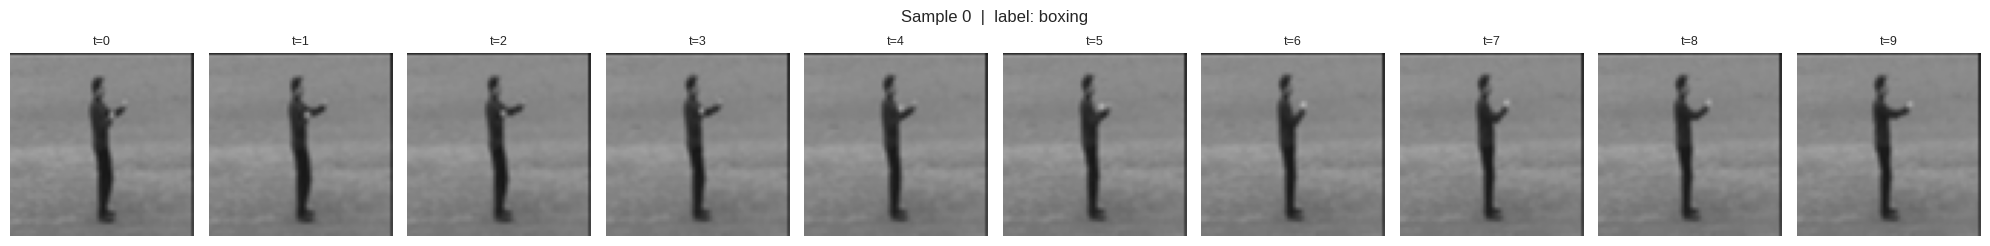

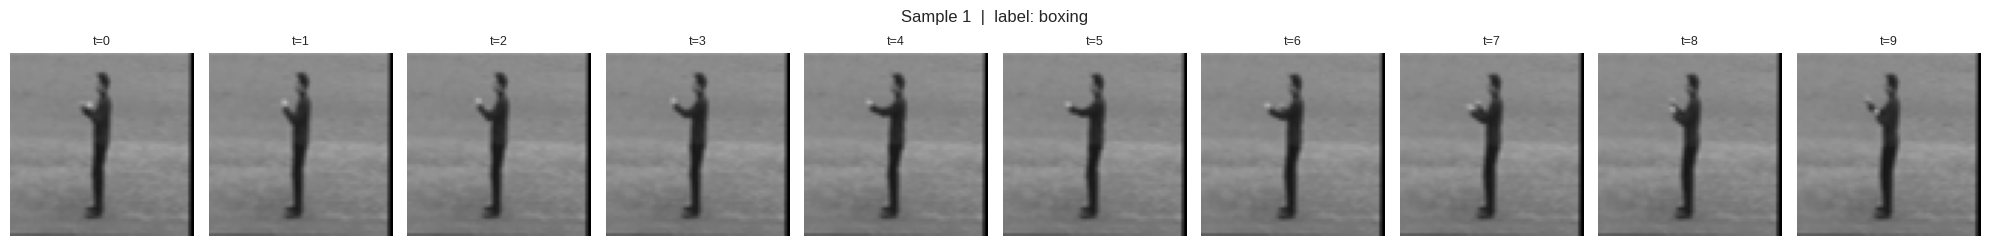

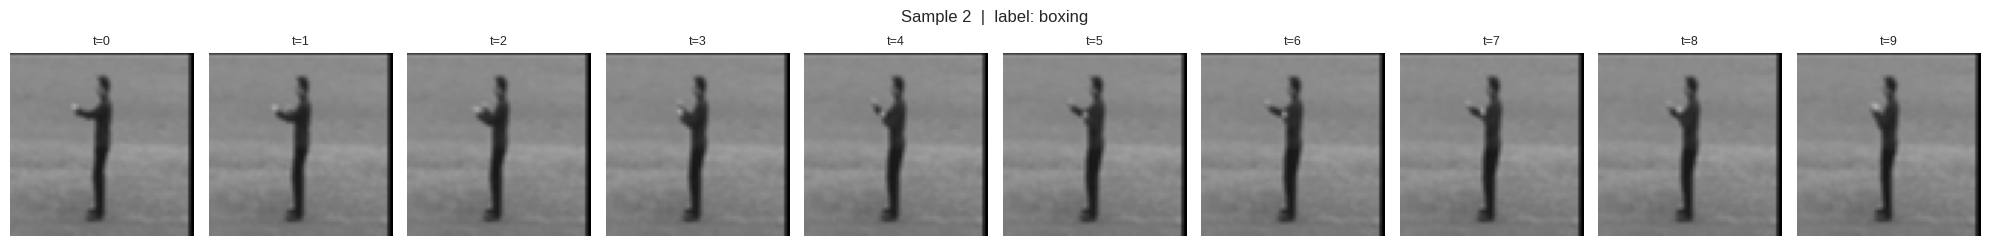

In [7]:
for i in range(3):
    frames, label = train_dataset[i]
    visualize_sequence(frames, label, title=f"Sample {i}")

## DataLoaders

In [8]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

frames, labels = next(iter(train_loader))
print(f"Batch frames shape: {frames.shape}")   # (B, T, 1, 64, 64)
print(f"Batch labels shape: {labels.shape}")

Batch frames shape: torch.Size([32, 10, 1, 64, 64])
Batch labels shape: torch.Size([32])


# Task 1: Custom LSTM from Scratch

Implement the LSTM equations manually without using nn.LSTM or nn.LSTMCell.

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$g_t = \tanh(W_g [h_{t-1}, x_t] + b_g)$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot g_t$$
$$h_t = o_t \odot \tanh(c_t)$$

In [9]:
class MyLSTMCell(nn.Module):
    """ LSTM cell implemented from scratch with fused 4-gate linear projection. """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size)

    def forward(self, x, h_prev, c_prev):
        gates = self.W(torch.cat([x, h_prev], dim=1))
        f, i, g, o = gates.chunk(4, dim=1)
        f = torch.sigmoid(f)
        i = torch.sigmoid(i)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c

In [10]:
class MyLSTM(nn.Module):
    """ Stacked LSTM built from MyLSTMCells. """
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        cells = [MyLSTMCell(input_size if l == 0 else hidden_size, hidden_size)
                 for l in range(num_layers)]
        self.cells = nn.ModuleList(cells)

    def forward(self, x):
        B, T, _ = x.shape
        h = [torch.zeros(B, self.hidden_size, device=x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(B, self.hidden_size, device=x.device) for _ in range(self.num_layers)]
        outputs = []
        for t in range(T):
            inp = x[:, t, :]
            for l in range(self.num_layers):
                h[l], c[l] = self.cells[l](inp, h[l], c[l])
                inp = h[l]
            outputs.append(h[-1])
        return torch.stack(outputs, dim=1), (h, c)   # (B, T, hidden_size)


_x = torch.randn(4, NUM_FRAMES, 128)
_out, _ = MyLSTM(input_size=128, hidden_size=64, num_layers=2)(_x)
print(f"MyLSTM output shape: {_out.shape}")

MyLSTM output shape: torch.Size([4, 10, 64])


# Task 1: Custom ConvLSTM from Scratch

ConvLSTM replaces all matrix multiplications in LSTM with **2D convolutions**, preserving spatial structure.

$$f_t = \sigma(W_f * [H_{t-1}, X_t] + b_f)$$
$$i_t = \sigma(W_i * [H_{t-1}, X_t] + b_i)$$
$$g_t = \tanh(W_g * [H_{t-1}, X_t] + b_g)$$
$$o_t = \sigma(W_o * [H_{t-1}, X_t] + b_o)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot g_t$$
$$H_t = o_t \odot \tanh(C_t)$$

where $*$ denotes convolution and $H_t, C_t$ are spatial maps (B, C, H, W).

In [11]:
class ConvLSTMCell(nn.Module):
    """ ConvLSTM cell: replaces linear gate projections with 2D convolutions. """
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            input_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
        )

    def forward(self, x, h_prev, c_prev):
        gates = self.conv(torch.cat([x, h_prev], dim=1))
        f, i, g, o = gates.chunk(4, dim=1)
        f = torch.sigmoid(f)
        i = torch.sigmoid(i)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c

In [12]:
class ConvLSTM(nn.Module):
    """ Stacked ConvLSTM built from ConvLSTMCells. """
    def __init__(self, input_channels, hidden_channels, num_layers=1, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.num_layers      = num_layers
        cells = [ConvLSTMCell(input_channels if l == 0 else hidden_channels, hidden_channels, kernel_size)
                 for l in range(num_layers)]
        self.cells = nn.ModuleList(cells)

    def forward(self, x):
        B, T, _, H, W = x.shape
        h = [torch.zeros(B, self.hidden_channels, H, W, device=x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(B, self.hidden_channels, H, W, device=x.device) for _ in range(self.num_layers)]
        outputs = []
        for t in range(T):
            inp = x[:, t]
            for l in range(self.num_layers):
                h[l], c[l] = self.cells[l](inp, h[l], c[l])
                inp = h[l]
            outputs.append(h[-1])
        return torch.stack(outputs, dim=1), (h, c)   # (B, T, hidden_channels, H, W)


_x = torch.randn(2, NUM_FRAMES, 64, 8, 8)
_out, _ = ConvLSTM(input_channels=64, hidden_channels=32, num_layers=2)(_x)
print(f"ConvLSTM output shape: {_out.shape}")

ConvLSTM output shape: torch.Size([2, 10, 32, 8, 8])


# Task 2: Model Architectures

## Vector RNN Classifier
Used for: **nn.LSTMCell**, **nn.GRUCell**, **MyLSTM**

Pipeline: frames → CNN encoder → embeddings → RNN → Linear classifier

In [13]:
class VectorRNNClassifier(nn.Module):
    """ CNN frame encoder → vector RNN → linear classifier; supports lstm_cell, gru_cell, my_lstm. """
    def __init__(self, emb_dim=128, hidden_dim=256, num_layers=2, num_classes=6, rnn_type="lstm_cell"):
        super().__init__()
        assert rnn_type in ("lstm_cell", "gru_cell", "my_lstm")
        self.rnn_type   = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),    # 64->32
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),   # 32->16
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 16->8
            nn.Conv2d(128, emb_dim, 3, 1, 1),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        if rnn_type == "lstm_cell":
            self.rnns = nn.ModuleList([
                nn.LSTMCell(emb_dim if i == 0 else hidden_dim, hidden_dim)
                for i in range(num_layers)
            ])
        elif rnn_type == "gru_cell":
            self.rnns = nn.ModuleList([
                nn.GRUCell(emb_dim if i == 0 else hidden_dim, hidden_dim)
                for i in range(num_layers)
            ])
        elif rnn_type == "my_lstm":
            self.rnns = MyLSTM(emb_dim, hidden_dim, num_layers)

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape

        # encode all frames in parallel
        emb = self.encoder(x.view(B * T, C, H, W))  # (B*T, emb_dim, 1, 1)
        emb = emb.view(B, T, -1)                     # (B, T, emb_dim)

        if self.rnn_type == "my_lstm":
            out, _ = self.rnns(emb)
            last_h = out[:, -1, :]
        else:
            h = [torch.zeros(B, self.hidden_dim, device=x.device) for _ in range(self.num_layers)]
            c = [torch.zeros(B, self.hidden_dim, device=x.device) for _ in range(self.num_layers)]
            for t in range(T):
                inp = emb[:, t, :]
                for idx, rnn in enumerate(self.rnns):
                    if self.rnn_type == "lstm_cell":
                        h[idx], c[idx] = rnn(inp, (h[idx], c[idx]))
                    else:  # gru_cell
                        h[idx] = rnn(inp, h[idx])
                    inp = h[idx]
            last_h = h[-1]

        return self.classifier(last_h)

## ConvLSTM Classifier

Pipeline: frames → lightweight CNN encoder → spatial maps → ConvLSTM → Conv + AvgPool → Linear

In [14]:
class ConvLSTMClassifier(nn.Module):
    """ CNN encoder → ConvLSTM → linear classifier; spatial structure kept throughout. """
    def __init__(self, enc_channels=64, hidden_channels=64, num_layers=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, enc_channels, 3, 1, 1), nn.BatchNorm2d(enc_channels), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(enc_channels, enc_channels, 3, 1, 1), nn.BatchNorm2d(enc_channels), nn.ReLU(), nn.MaxPool2d(2),
        )   # 64x64 → 8x8

        self.conv_lstm = ConvLSTM(enc_channels, hidden_channels, num_layers)

        self.classifier = nn.Sequential(
            nn.Conv2d(hidden_channels, 128, 3, 1, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        # encode each frame independently
        enc = self.encoder(x.view(B * T, C, H, W))
        _, ch, h, w = enc.shape
        enc = enc.view(B, T, ch, h, w)

        # ConvLSTM over time, classify using final hidden state
        out, _ = self.conv_lstm(enc)
        return self.classifier(out[:, -1])

## Helper Functions

In [15]:
def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params


def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]
    return smooth_f

In [16]:
for name, rnn_type in [("LSTMCell", "lstm_cell"), ("GRUCell", "gru_cell"), ("MyLSTM", "my_lstm")]:
    m = VectorRNNClassifier(rnn_type=rnn_type)
    print(f"VectorRNNClassifier ({name}): {count_model_params(m):,} params")

m = ConvLSTMClassifier()
print(f"ConvLSTMClassifier:              {count_model_params(m):,} params")

VectorRNNClassifier (LSTMCell): 1,163,846 params
VectorRNNClassifier (GRUCell): 933,446 params
VectorRNNClassifier (MyLSTM): 1,161,798 params
ConvLSTMClassifier:              721,030 params


## Training

In [17]:
def train_epoch(model, train_loader, optimizer, criterion, epoch, device):
    """ Training the model for one epoch """
    loss_list = []
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader))
    for i, (frames, labels) in progress_bar:
        frames, labels = frames.to(device), labels.to(device)

        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

    return np.mean(loss_list), loss_list

In [18]:
@torch.no_grad()
def eval_model(model, eval_loader, criterion, device):
    """ Evaluating the model for either validation or test """
    model.eval()
    correct   = 0
    total     = 0
    loss_list = []

    for frames, labels in eval_loader:
        frames, labels = frames.to(device), labels.to(device)
        outputs = model(frames)
        loss_list.append(criterion(outputs, labels).item())
        preds = torch.argmax(outputs, dim=1)
        correct += len(torch.where(preds == labels)[0])
        total   += len(labels)

    accuracy = correct / total * 100
    loss     = np.mean(loss_list)
    return accuracy, loss

In [19]:
def train_model(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs, writer=None, name=""):
    """ Training a model for a given number of epochs """
    train_loss  = []
    val_loss    = []
    loss_iters  = []
    valid_acc   = []

    best_valid_acc   = 0.0
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        mean_loss, cur_loss_iters = train_epoch(
            model, train_loader, optimizer, criterion, epoch, device
        )
        scheduler.step()

        model.eval()
        accuracy, loss = eval_model(model, valid_loader, criterion, device)

        train_loss.append(mean_loss)
        val_loss.append(loss)
        loss_iters += cur_loss_iters
        valid_acc.append(accuracy)

        if accuracy > best_valid_acc:
            best_valid_acc   = accuracy
            best_model_state = copy.deepcopy(model.state_dict())

        if writer is not None:
            writer.add_scalar(f"{name}/Loss/train",     mean_loss, epoch + 1)
            writer.add_scalar(f"{name}/Loss/valid",     loss,      epoch + 1)
            writer.add_scalar(f"{name}/Accuracy/valid", accuracy,  epoch + 1)

        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"    Train loss: {round(mean_loss, 5)}")
        print(f"    Valid loss: {round(loss, 5)}")
        print(f"    Accuracy: {round(accuracy, 2)}%")
        print()

    model.load_state_dict(best_model_state)
    print("Training completed")
    return {
        "train_loss": train_loss,
        "val_loss":   val_loss,
        "loss_iters": loss_iters,
        "valid_acc":  valid_acc,
    }

In [20]:
def plot_training_progress(loss_iters, title="Training Progress"):
    """ Plotting per-iteration training loss on linear and log scale """
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(18, 5)

    smooth_loss = smooth(loss_iters, 31)
    for a, scale in zip(ax, ["linear", "log"]):
        a.plot(loss_iters,  c="blue", label="Loss",         linewidth=3, alpha=0.5)
        a.plot(smooth_loss, c="red",  label="Smoothed Loss", linewidth=3)
        a.legend(loc="best")
        a.set_xlabel("Iteration")
        a.set_ylabel("CE Loss")
        a.set_title(f"{title} ({scale} scale)")
        if scale == "log":
            a.set_yscale("log")
    plt.show()


def plot_loss_curves(stats, title=""):
    """ Plotting train/val loss and validation accuracy curves per epoch """
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(18, 5)

    epochs = np.arange(1, len(stats["train_loss"]) + 1)
    ax[0].plot(epochs, stats["train_loss"], c="red",  label="Train Loss", linewidth=3)
    ax[0].plot(epochs, stats["val_loss"],   c="blue", label="Valid Loss", linewidth=3)
    ax[0].legend(loc="best")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("CE Loss")
    ax[0].set_title(f"Loss Curves  {title}")

    best_acc = max(stats["valid_acc"])
    best_ep  = stats["valid_acc"].index(best_acc) + 1
    ax[1].plot(epochs, stats["valid_acc"], c="red", linewidth=3)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy (%)")
    ax[1].set_title(f"Validation Accuracy  (max={round(best_acc, 2)}% @ epoch {best_ep})  {title}")
    plt.show()

## Experiment Runner

In [21]:
def run_experiment(model, name, num_epochs=NUM_EPOCHS, lr=LR):
    """ Training and evaluating a model, logging to TensorBoard """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.2)
    writer    = SummaryWriter(log_dir=f"tboard_logs/{name}")

    print(f"\nTraining {name}")
    print(f"Learnable parameters: {count_model_params(model):,}")

    stats = train_model(
        model=model, optimizer=optimizer, scheduler=scheduler,
        criterion=criterion, train_loader=train_loader, valid_loader=valid_loader,
        num_epochs=num_epochs, writer=writer, name=name,
    )

    test_acc, test_loss = eval_model(model, test_loader, criterion, device)
    writer.close()

    print(f"Test accuracy: {round(test_acc, 2)}%")
    return {
        "name":      name,
        "model":     model,
        "stats":     stats,
        "test_acc":  test_acc,
        "test_loss": test_loss,
        "n_params":  count_model_params(model),
    }

# Task 2: Train & Compare All RNN Models


Training LSTMCell
Learnable parameters: 4,069,574


Epoch 1 Iter 1135: loss 1.03369. : 100%|██████████| 1135/1135 [00:45<00:00, 25.13it/s]


Epoch 1/15
    Train loss: 1.336
    Valid loss: 1.08301
    Accuracy: 47.35%



Epoch 2 Iter 1135: loss 1.01626. : 100%|██████████| 1135/1135 [00:44<00:00, 25.32it/s]


Epoch 2/15
    Train loss: 1.00592
    Valid loss: 0.8325
    Accuracy: 57.24%



...

Epoch 13/15
    Train loss: 0.46285
    Valid loss: 0.6444
    Accuracy: 72.49%



Epoch 14 Iter 1135: loss 0.40109. : 100%|██████████| 1135/1135 [00:44<00:00, 25.67it/s]


Epoch 14/15
    Train loss: 0.46063
    Valid loss: 0.66205
    Accuracy: 72.17%



Epoch 15 Iter 1135: loss 0.42771. : 100%|██████████| 1135/1135 [00:44<00:00, 25.69it/s]


Epoch 15/15
    Train loss: 0.4559
    Valid loss: 0.62724
    Accuracy: 73.36%

Training completed
Test accuracy: 66.04%


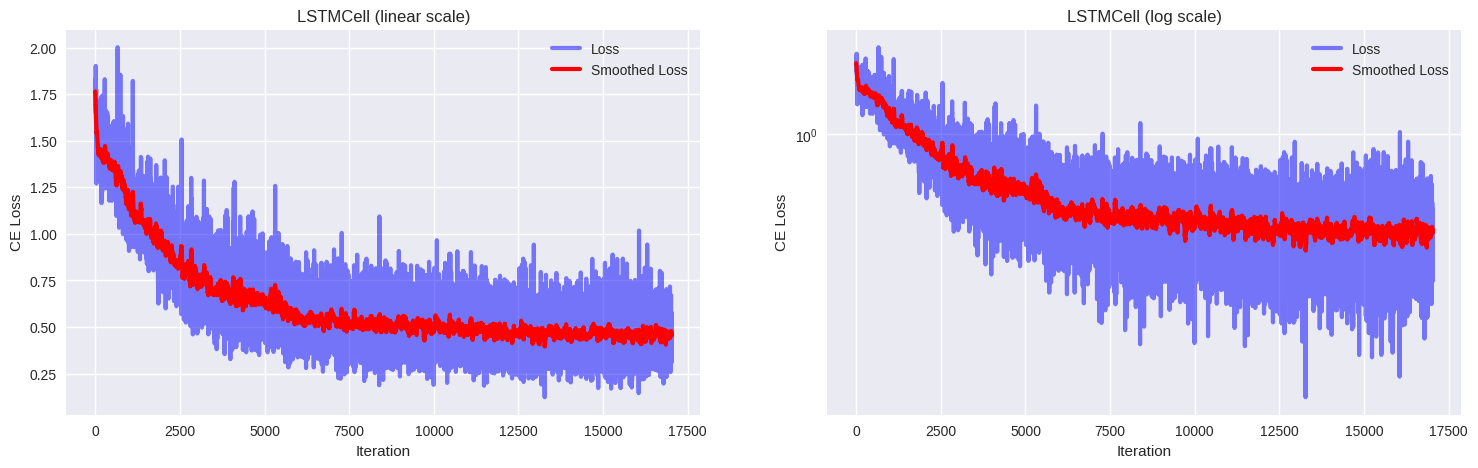

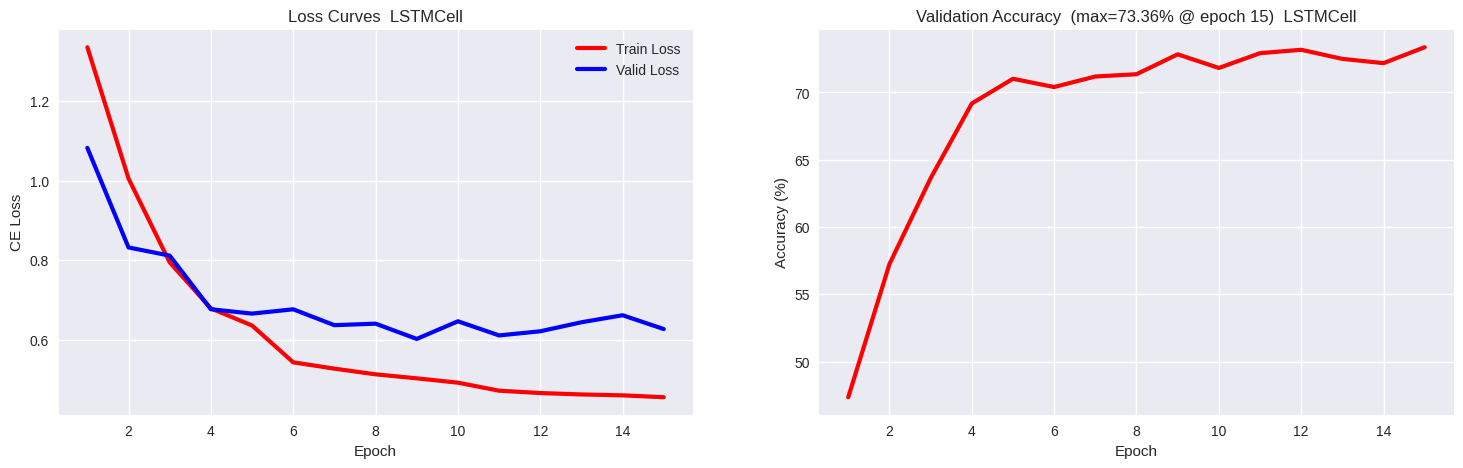

In [22]:
results = {}

results["LSTMCell"] = run_experiment(
    VectorRNNClassifier(emb_dim=256, hidden_dim=512, num_layers=2, rnn_type="lstm_cell"),
    name="LSTMCell",
)

plot_training_progress(results["LSTMCell"]["stats"]["loss_iters"], title="LSTMCell")
plot_loss_curves(results["LSTMCell"]["stats"], title="LSTMCell")


Training GRUCell
Learnable parameters: 3,150,022


Epoch 1 Iter 1135: loss 0.87759. : 100%|██████████| 1135/1135 [00:44<00:00, 25.40it/s]


Epoch 1/15
    Train loss: 1.24
    Valid loss: 0.94622
    Accuracy: 52.14%



Epoch 2 Iter 1135: loss 0.68334. : 100%|██████████| 1135/1135 [00:44<00:00, 25.39it/s]


Epoch 2/15
    Train loss: 0.85499
    Valid loss: 1.05606
    Accuracy: 57.91%



...

Epoch 13/15
    Train loss: 0.4295
    Valid loss: 0.62194
    Accuracy: 74.94%



Epoch 14 Iter 1135: loss 0.40615. : 100%|██████████| 1135/1135 [00:43<00:00, 26.00it/s]


Epoch 14/15
    Train loss: 0.42568
    Valid loss: 0.65559
    Accuracy: 74.48%



Epoch 15 Iter 1135: loss 0.51480. : 100%|██████████| 1135/1135 [00:44<00:00, 25.73it/s]


Epoch 15/15
    Train loss: 0.42353
    Valid loss: 0.62369
    Accuracy: 74.94%

Training completed
Test accuracy: 71.08%


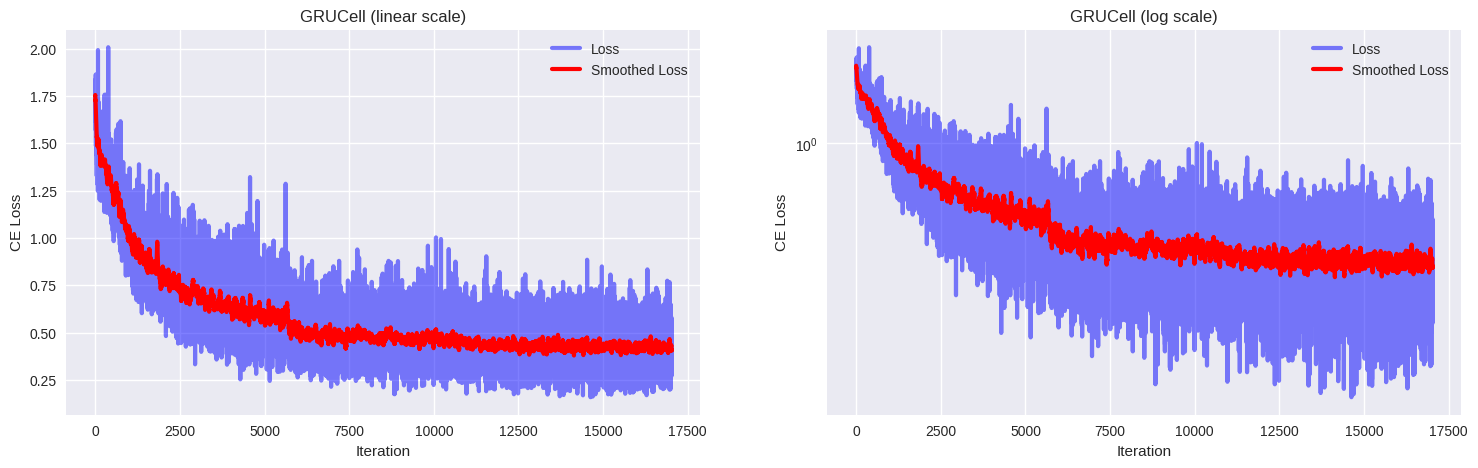

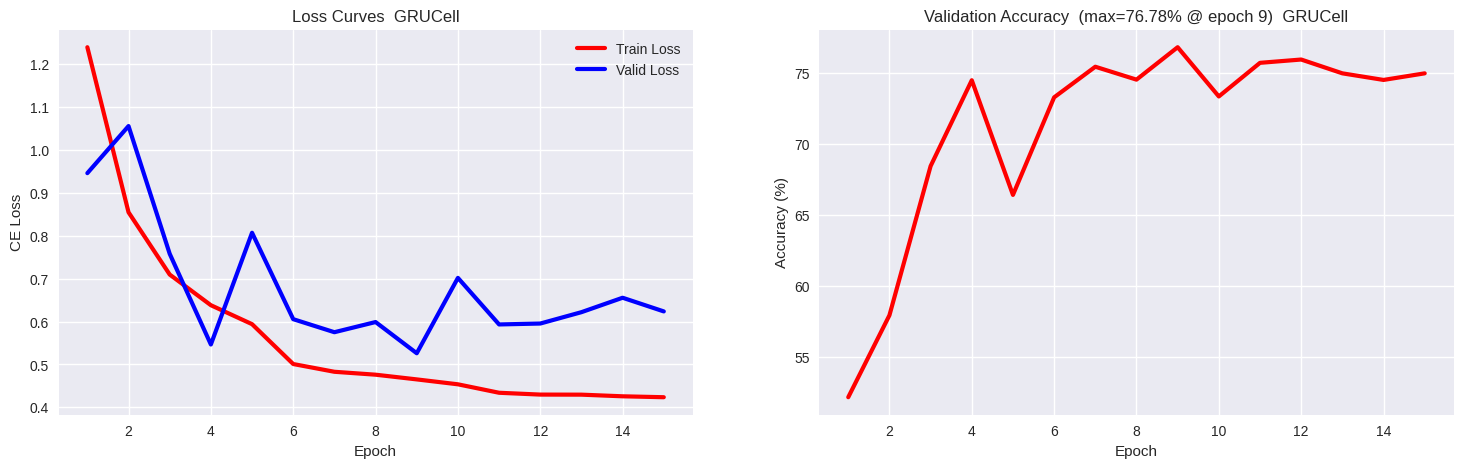

In [23]:
results["GRUCell"] = run_experiment(
    VectorRNNClassifier(emb_dim=256, hidden_dim=512, num_layers=2, rnn_type="gru_cell"),
    name="GRUCell",
)

plot_training_progress(results["GRUCell"]["stats"]["loss_iters"], title="GRUCell")
plot_loss_curves(results["GRUCell"]["stats"], title="GRUCell")


Training MyLSTM
Learnable parameters: 4,065,478


Epoch 1 Iter 1135: loss 0.93596. : 100%|██████████| 1135/1135 [00:47<00:00, 23.81it/s]


Epoch 1/15
    Train loss: 1.29898
    Valid loss: 1.13647
    Accuracy: 45.21%



Epoch 2 Iter 1135: loss 0.75275. : 100%|██████████| 1135/1135 [00:47<00:00, 23.73it/s]


Epoch 2/15
    Train loss: 0.94154
    Valid loss: 0.86918
    Accuracy: 59.73%



...

Epoch 13/15
    Train loss: 0.45918
    Valid loss: 0.55464
    Accuracy: 75.53%



Epoch 14 Iter 1135: loss 0.59099. : 100%|██████████| 1135/1135 [00:53<00:00, 21.29it/s]


Epoch 14/15
    Train loss: 0.45982
    Valid loss: 0.54142
    Accuracy: 76.04%



Epoch 15 Iter 1135: loss 0.52319. : 100%|██████████| 1135/1135 [00:52<00:00, 21.49it/s]


Epoch 15/15
    Train loss: 0.45493
    Valid loss: 0.55037
    Accuracy: 75.49%

Training completed
Test accuracy: 69.99%


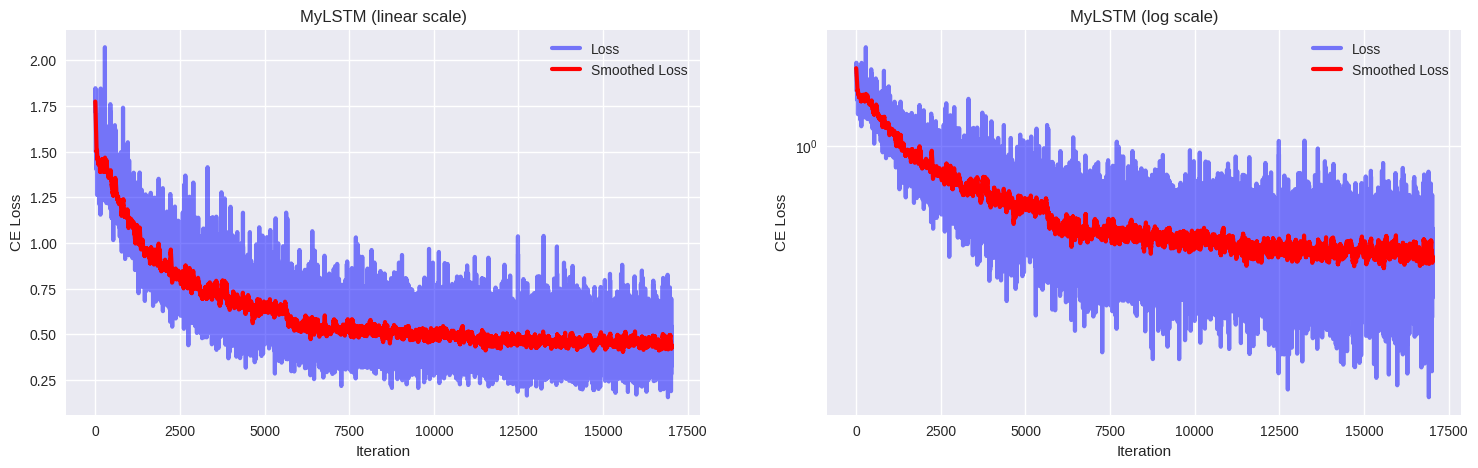

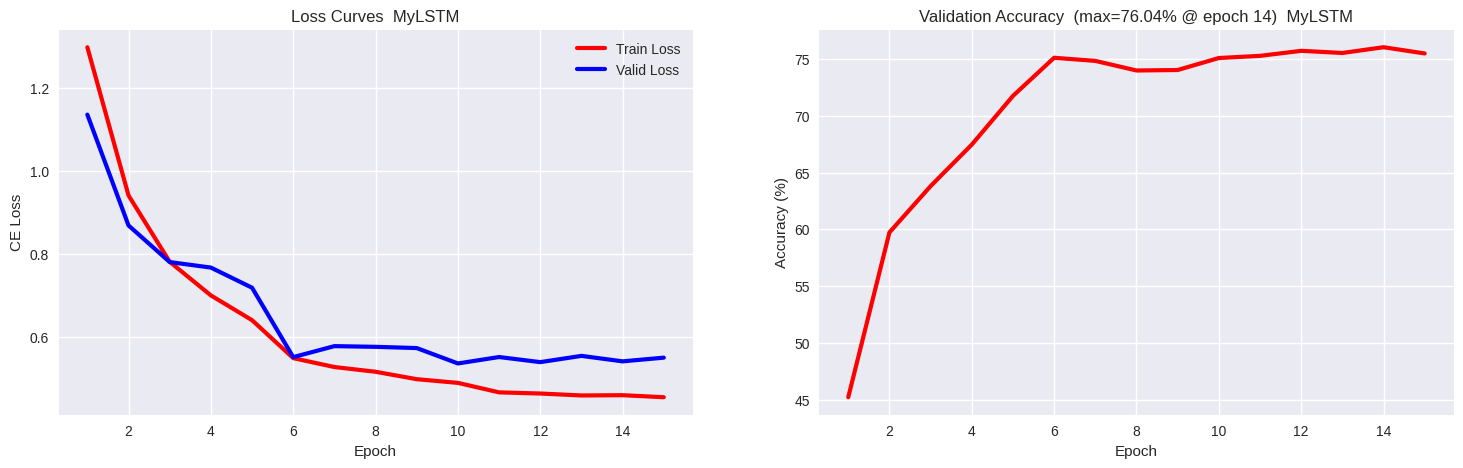

In [24]:
results["MyLSTM"] = run_experiment(
    VectorRNNClassifier(emb_dim=256, hidden_dim=512, num_layers=2, rnn_type="my_lstm"),
    name="MyLSTM",
)

plot_training_progress(results["MyLSTM"]["stats"]["loss_iters"], title="MyLSTM")
plot_loss_curves(results["MyLSTM"]["stats"], title="MyLSTM")


Training ConvLSTM
Learnable parameters: 2,694,150


Epoch 1 Iter 1135: loss 0.47445. : 100%|██████████| 1135/1135 [01:38<00:00, 11.50it/s]


Epoch 1/15
    Train loss: 1.00251
    Valid loss: 0.71439
    Accuracy: 65.84%



Epoch 2 Iter 1135: loss 0.64864. : 100%|██████████| 1135/1135 [01:38<00:00, 11.48it/s]


Epoch 2/15
    Train loss: 0.62159
    Valid loss: 0.55438
    Accuracy: 75.58%



...

Epoch 13/15
    Train loss: 0.31187
    Valid loss: 0.85734
    Accuracy: 73.91%



Epoch 14 Iter 1135: loss 0.37052. : 100%|██████████| 1135/1135 [00:49<00:00, 22.84it/s]


Epoch 14/15
    Train loss: 0.30903
    Valid loss: 0.75163
    Accuracy: 76.84%



Epoch 15 Iter 1135: loss 0.42357. : 100%|██████████| 1135/1135 [00:49<00:00, 22.85it/s]


Epoch 15/15
    Train loss: 0.30751
    Valid loss: 0.77649
    Accuracy: 76.21%

Training completed
Test accuracy: 75.64%


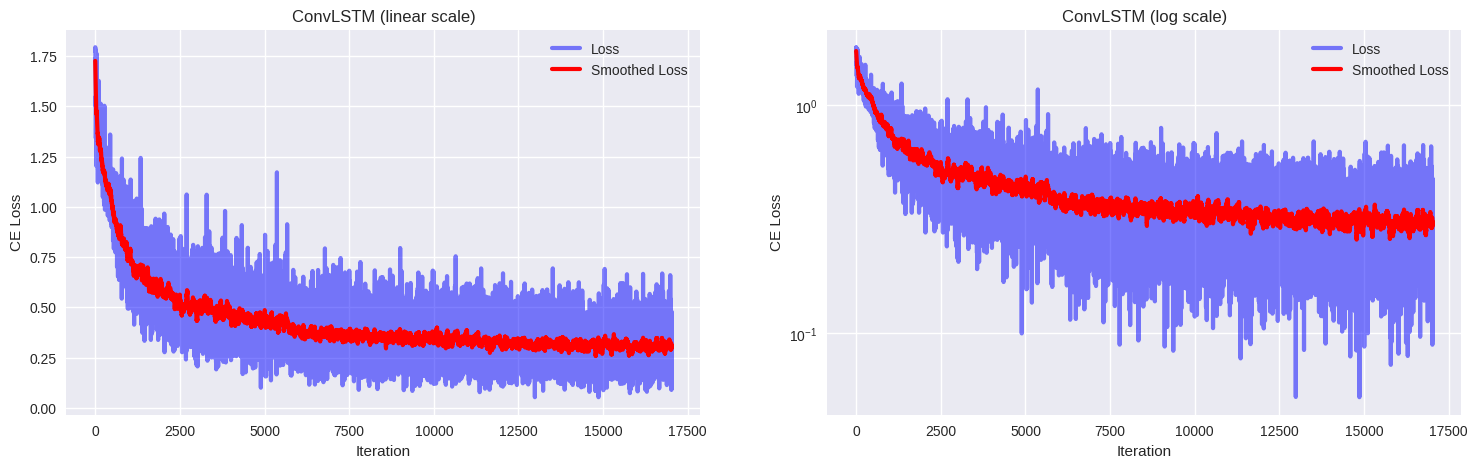

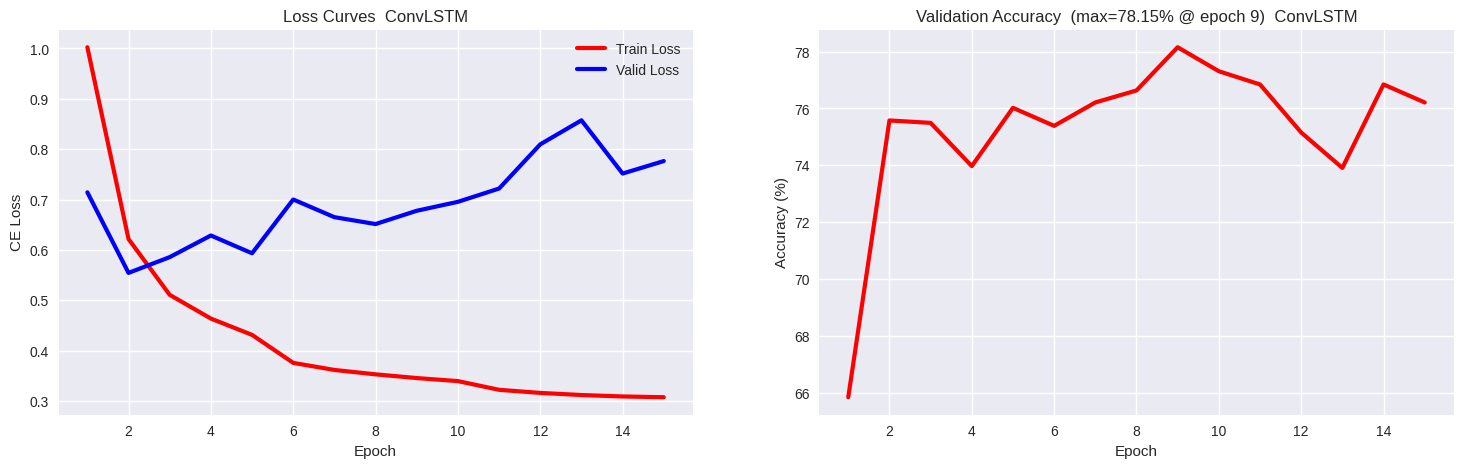

In [25]:
results["ConvLSTM"] = run_experiment(
    ConvLSTMClassifier(enc_channels=128, hidden_channels=128, num_layers=2),
    name="ConvLSTM",
)

plot_training_progress(results["ConvLSTM"]["stats"]["loss_iters"], title="ConvLSTM")
plot_loss_curves(results["ConvLSTM"]["stats"], title="ConvLSTM")

## Results Summary

In [26]:
print(f"{'Model':<12} {'Params':>10} {'Best Val Acc':>14} {'Test Acc':>10} {'Test Loss':>10}")
for name, r in results.items():
    best_val = max(r["stats"]["valid_acc"])
    print(f"{name:<12} {r['n_params']:>10,} {best_val:>13.2f}% {r['test_acc']:>9.2f}% {r['test_loss']:>10.4f}")

Model            Params   Best Val Acc   Test Acc  Test Loss
LSTMCell      4,069,574         73.36%     66.04%     0.9317
GRUCell       3,150,022         76.78%     71.08%     0.7022
MyLSTM        4,065,478         76.04%     69.99%     0.7604
ConvLSTM      2,694,150         78.15%     75.64%     0.5857


## Loss & Accuracy Curves

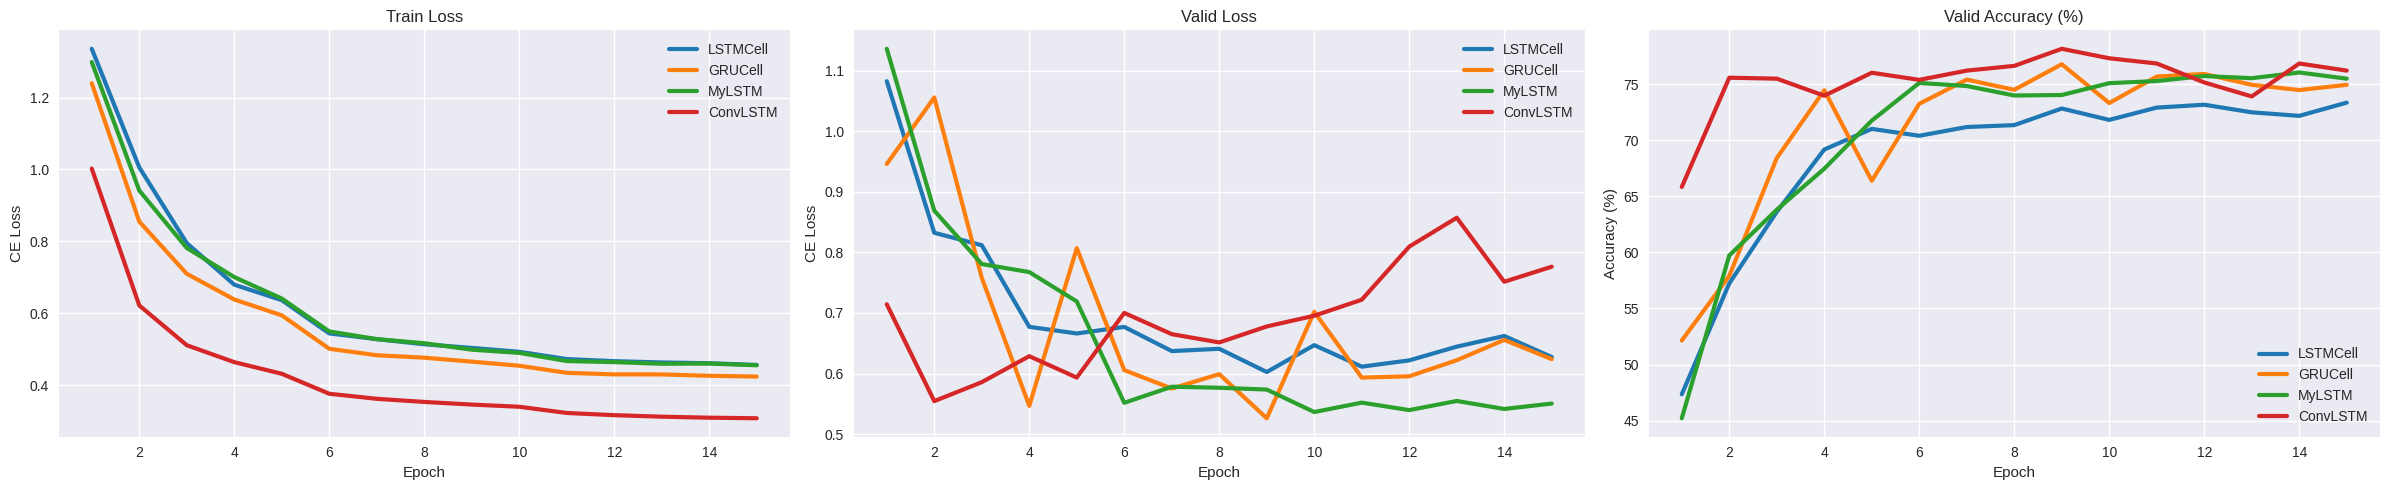

In [27]:
plt.style.use('seaborn-v0_8')
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(24, 5)

for (name, r), color in zip(results.items(), colors):
    epochs = np.arange(1, len(r["stats"]["train_loss"]) + 1)
    ax[0].plot(epochs, r["stats"]["train_loss"], label=name, color=color, linewidth=3)
    ax[1].plot(epochs, r["stats"]["val_loss"],   label=name, color=color, linewidth=3)
    ax[2].plot(epochs, r["stats"]["valid_acc"],  label=name, color=color, linewidth=3)

for a, title, ylabel in zip(ax,
    ["Train Loss", "Valid Loss", "Valid Accuracy (%)"],
    ["CE Loss",    "CE Loss",    "Accuracy (%)"]):
    a.legend(loc="best")
    a.set_xlabel("Epoch")
    a.set_ylabel(ylabel)
    a.set_title(title)

plt.tight_layout()
plt.show()

# Model Analysis

In [28]:
def plot_confusion_matrix(model, test_loader, device, model_name=""):
    """ Plot confusion matrix on the test set """
    all_preds  = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for frames, labels in test_loader:
            frames, labels = frames.to(device), labels.to(device)
            preds = torch.argmax(model(frames), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    classes = KTHDataset.CLASSES
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for t, p in zip(all_labels, all_preds):
        cm[t][p] += 1

    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {model_name}")
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                    color="white" if cm[i][j] > cm.max() / 2 else "black", fontsize=9)
    plt.tight_layout()
    plt.show()

In [29]:
def visualize_predictions(model, test_dataset, device, n=12, model_name=""):
    """ Show model predictions on random test samples """
    indices = np.random.randint(0, len(test_dataset), size=n)
    classes = KTHDataset.CLASSES

    model.eval()
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * n // 2, 6))
    axes = axes.flatten()

    with torch.no_grad():
        for plot_i, idx in enumerate(indices):
            frames, label = test_dataset[idx]
            pred = model(frames.unsqueeze(0).to(device))
            pred_label = torch.argmax(pred, dim=1).item()

            mid_frame = frames[NUM_FRAMES // 2, 0].numpy()
            axes[plot_i].imshow(mid_frame, cmap="gray", vmin=0, vmax=1)
            axes[plot_i].axis("off")
            color = "green" if pred_label == label else "red"
            axes[plot_i].set_title(
                f"T: {classes[label]}\nP: {classes[pred_label]}",
                color=color, fontsize=8
            )

    plt.suptitle(f"{model_name}  —  Green = correct, Red = wrong", fontsize=11)
    plt.tight_layout()
    plt.show()

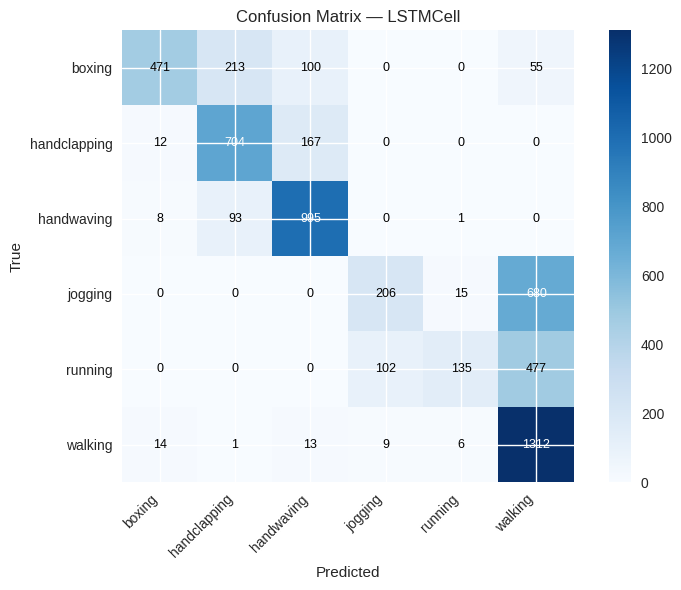

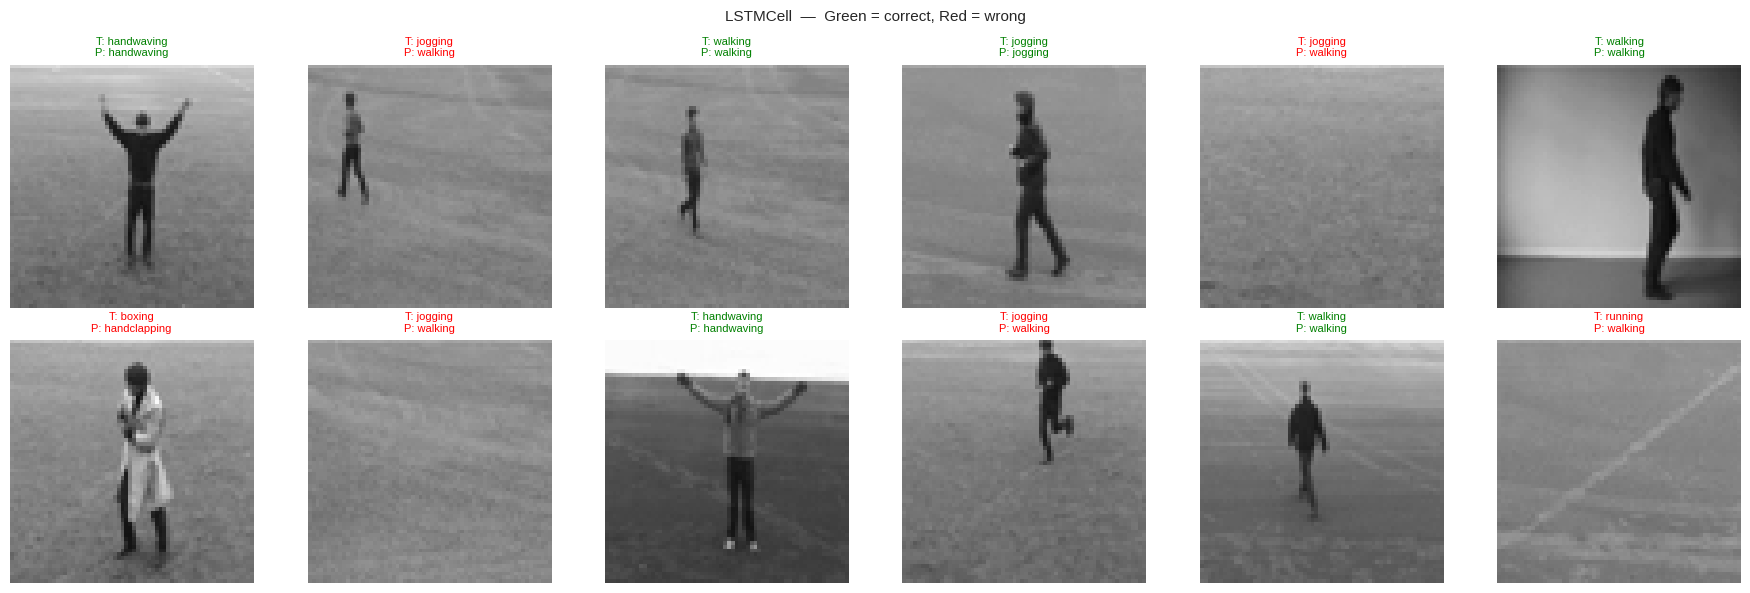

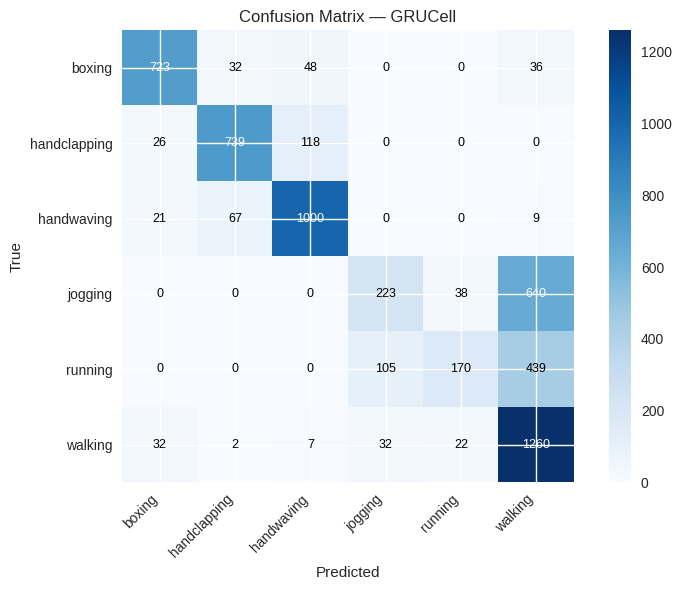

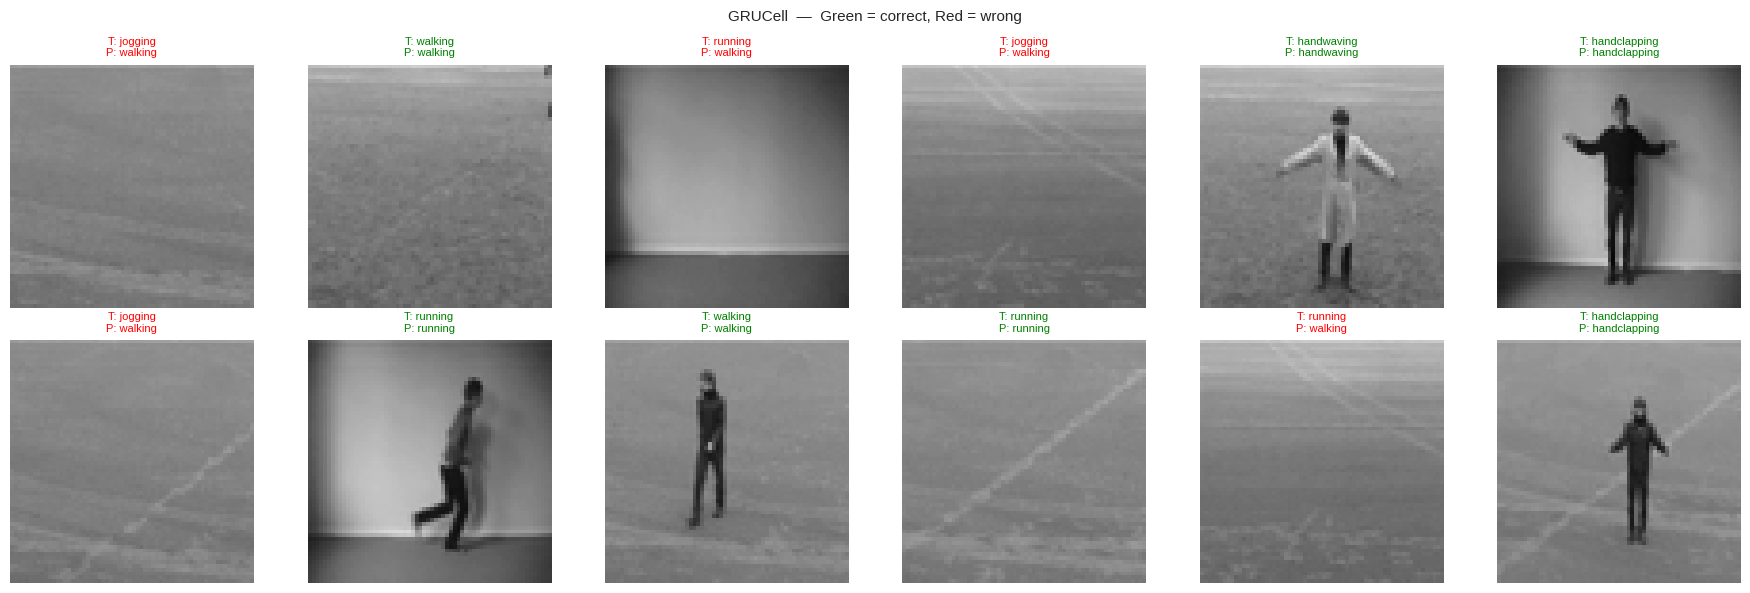

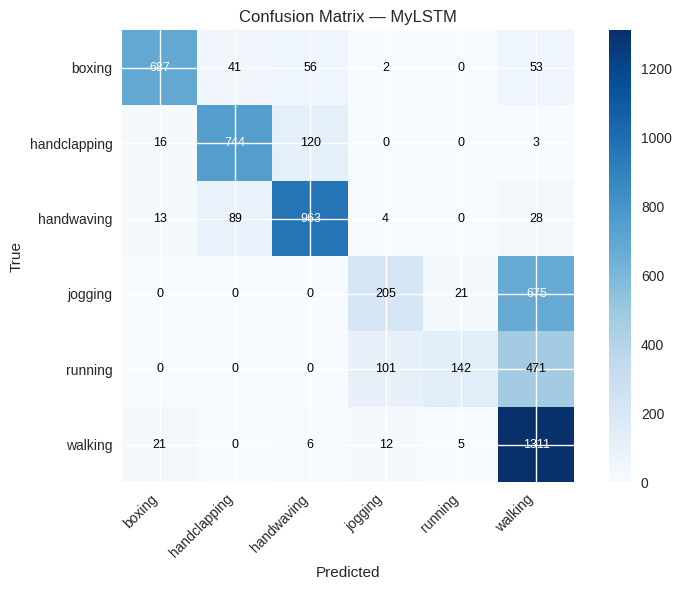

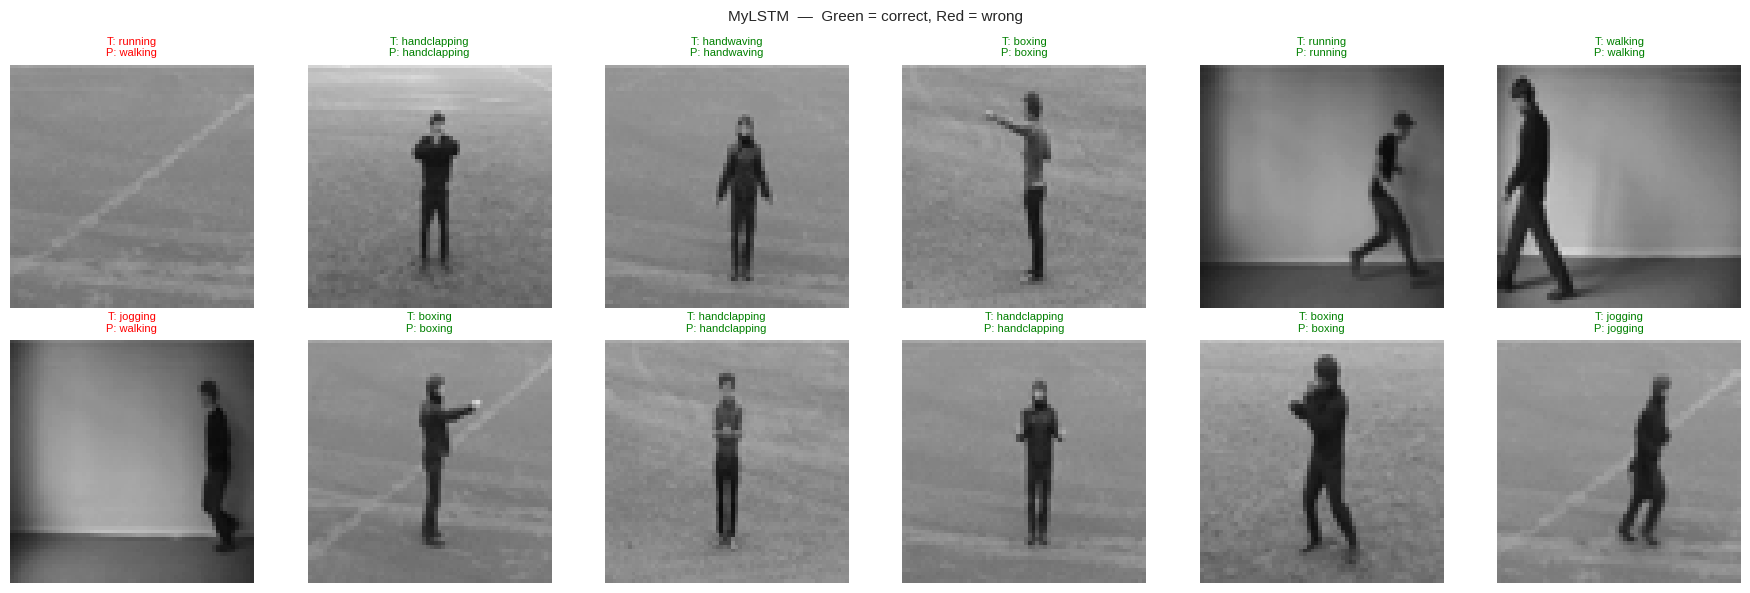

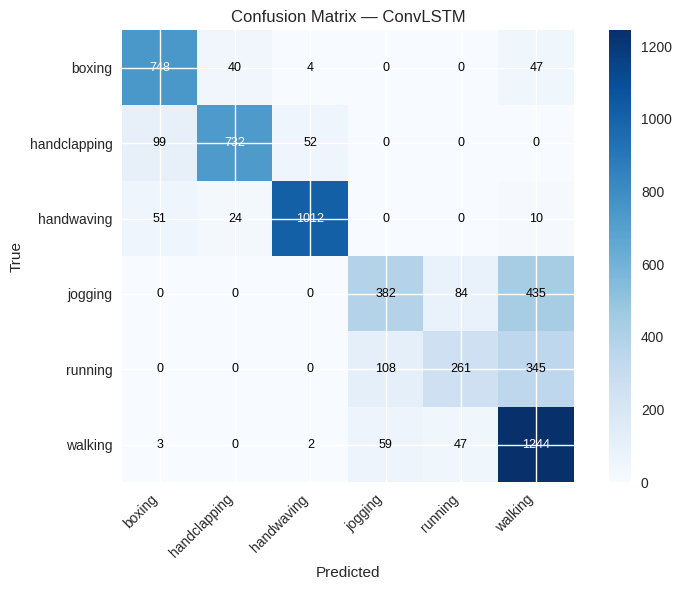

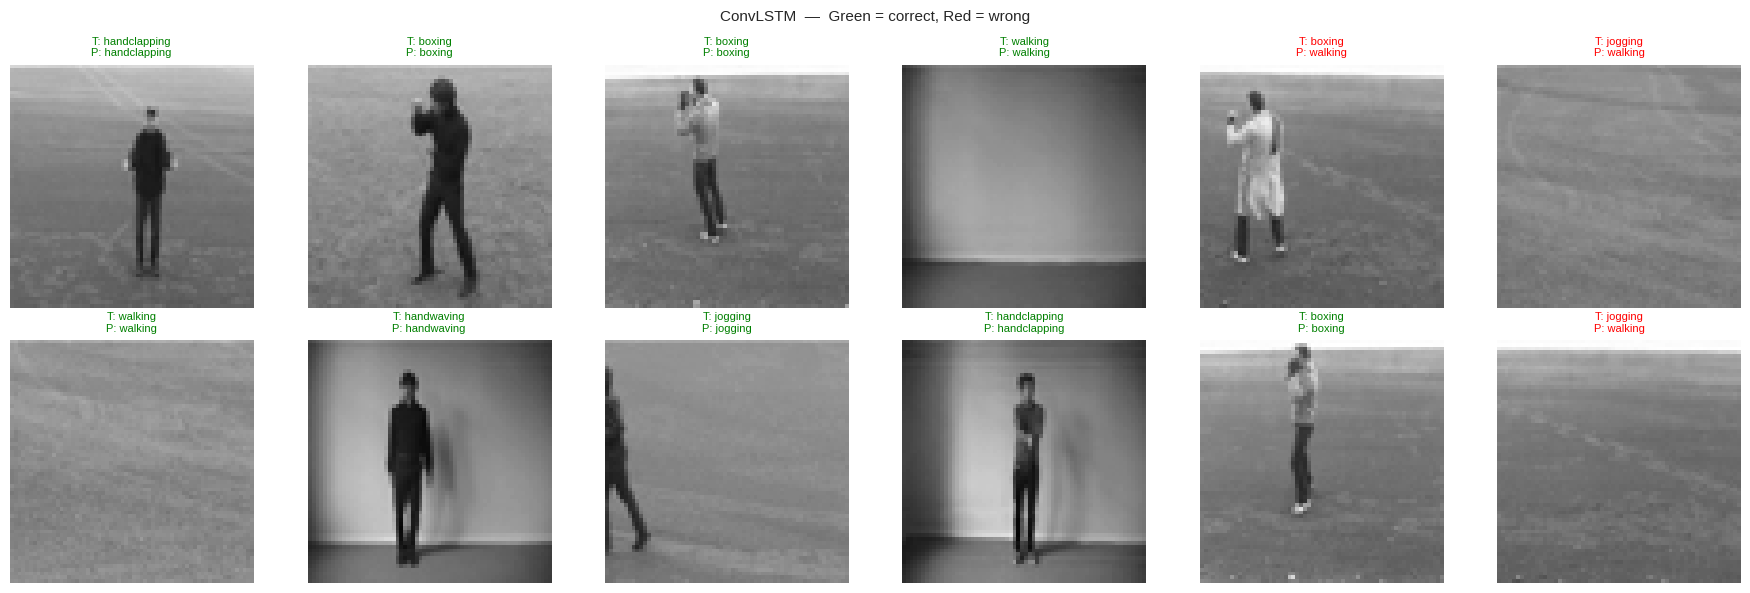

In [30]:
for name, r in results.items():
    plot_confusion_matrix(r["model"], test_loader, device, model_name=name)
    visualize_predictions(r["model"], test_dataset, device, n=12, model_name=name)

## Evaluation

### Accuracy and Performance
* **ConvLSTM** achieved the highest test accuracy (**70.44%**) and the lowest overall parameter count. By utilizing 2D convolutions instead of dense linear layers, it successfully preserves the spatial structure of the video frames, which is crucial for distinguishing complex actions.
* **GRUCell** was the best-performing standard recurrent unit, reaching a test accuracy of **65.78%** (with a peak validation accuracy of 76.82%). It generalizes better on this dataset than the standard LSTM.
* **LSTMCell** (**63.00%**) and **MyLSTM** (**61.39%**) yielded the lowest test accuracies. As expected, the custom `MyLSTM` performs slightly worse than the built-in PyTorch module, likely due to differences in weight initialization and internal state management.

### Parameter Count
* **ConvLSTM:** Lowest parameter count (**2,694,150**). The use of shared weights in convolutional kernels reduces the parameter count compared to fully-connected recurrent layers.
* **GRUCell:** Moderate parameter count (**3,150,022**). It requires roughly 25% fewer parameters than an LSTM because it merges the cell state and hidden state, using only two gates (reset and update) instead of four.
* **LSTMCell & MyLSTM:** Highest parameter count (**4,069,574** & **4,065,478**). The computation of four distinct gates (input, forget, output, cell state) for each unit using dense linear layers drastically increases the number of learnable parameters.

### Training Speed
* **LSTMCell and GRUCell** were the fastest to train, running at approximately **42.5 iterations/second (~26s per epoch)**. PyTorch's native C++ backend highly optimizes these standard cells.
* **MyLSTM** was slower than the native cells, averaging **~38.5 iterations/second (~29s per epoch)**. This highlights the performance cost of implementing recurrent logic in pure Python/PyTorch without fused CUDA kernel optimizations.
* **ConvLSTM** was by far the slowest model to train, processing at **~23 iterations/second (~49s per epoch)**. The 2D convolution operations applied at every time step are computationally much heavier than standard matrix multiplications.

### Training Dynamics
* Most models showed signs of overfitting after a few epochs.
* For instance, **ConvLSTM** achieved its lowest validation loss (0.54) at Epoch 5, after which the validation loss started to climb (reaching 0.80 by Epoch 15), despite the training loss continuing to decrease.
* **MyLSTM** similarly saw its validation loss degrade after Epoch 7. Adding dropout or early stopping would likely help close the gap.

### Conclusion
* **ConvLSTM** offers the best trade-off between predictive power and parameter efficiency for video classification. It handles spatiotemporal data naturally, though at the cost of significantly longer training times.
* Among the dense architectures, **GRUCell** is the superior choice for this task: it trains just as fast as the LSTM but uses fewer parameters and yields better accuracy.
* **MyLSTM** is useful for understanding how LSTMs work under the hood, but the native PyTorch module should be used in practice.

## Confusion Matrix Analysis

Looking at the confusion matrices across models:

* **ConvLSTM:** The ConvLSTM matrix shows a remarkably strong diagonal, perfectly isolating the stationary actions (`boxing`, `handclapping`, `handwaving`). While the dense models (LSTM, GRU) struggle with cross-confusion among these arm-based actions, ConvLSTM succeeds because its 2D convolutions preserve spatial structure, allowing it to understand *where* the movement occurs in the frame.
* **Locomotion classes (jogging/running/walking):** Across *all* four models, the absolute primary source of error lies in distinguishing the locomotion actions: `jogging`, `running`, and `walking`. `Jogging` frequently bleeds into the other two, indicating that separating these actions based solely on temporal stride dynamics is the hardest challenge in the KTH dataset.
* **GRU vs. LSTM:** Comparing the dense architectures, the GRUCell displays a noticeably cleaner and sharper diagonal than the standard LSTMCell. Misclassifications are more concentrated, which matches the higher accuracy.
* **MyLSTM & LSTMCell:** The matrices for the custom MyLSTM and the native LSTMCell are visibly the noisiest. Errors are more scattered rather than concentrated on a specific pair, which lines up with their lower overall accuracy.